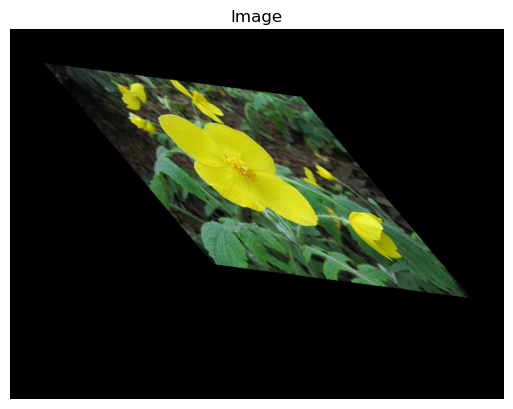

In [1]:
import cv2
import numpy as np
img = cv2.imread('/Users/xh/workspaces/jupyter/opencv-example/2入门/opencv入门/image0.JPG', 1)
imgInfo = img.shape
height = imgInfo[0]
width = imgInfo[1]
#src 3->dst 3 (左上角 左下角 右上角)
matSrc = np.float32([[0,0],[0,height-1],[width-1,0]])
matDst = np.float32([[50,50],[300,height-200],[width-300,100]])
#组合
matAffine = cv2.getAffineTransform(matSrc,matDst)# mat 1 src 2 dst
dst = cv2.warpAffine(img,matAffine,(width,height))
import matplotlib.pyplot as plt
img_rgb = cv2.cvtColor(dst, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title('Image')
plt.axis('off')
plt.show()


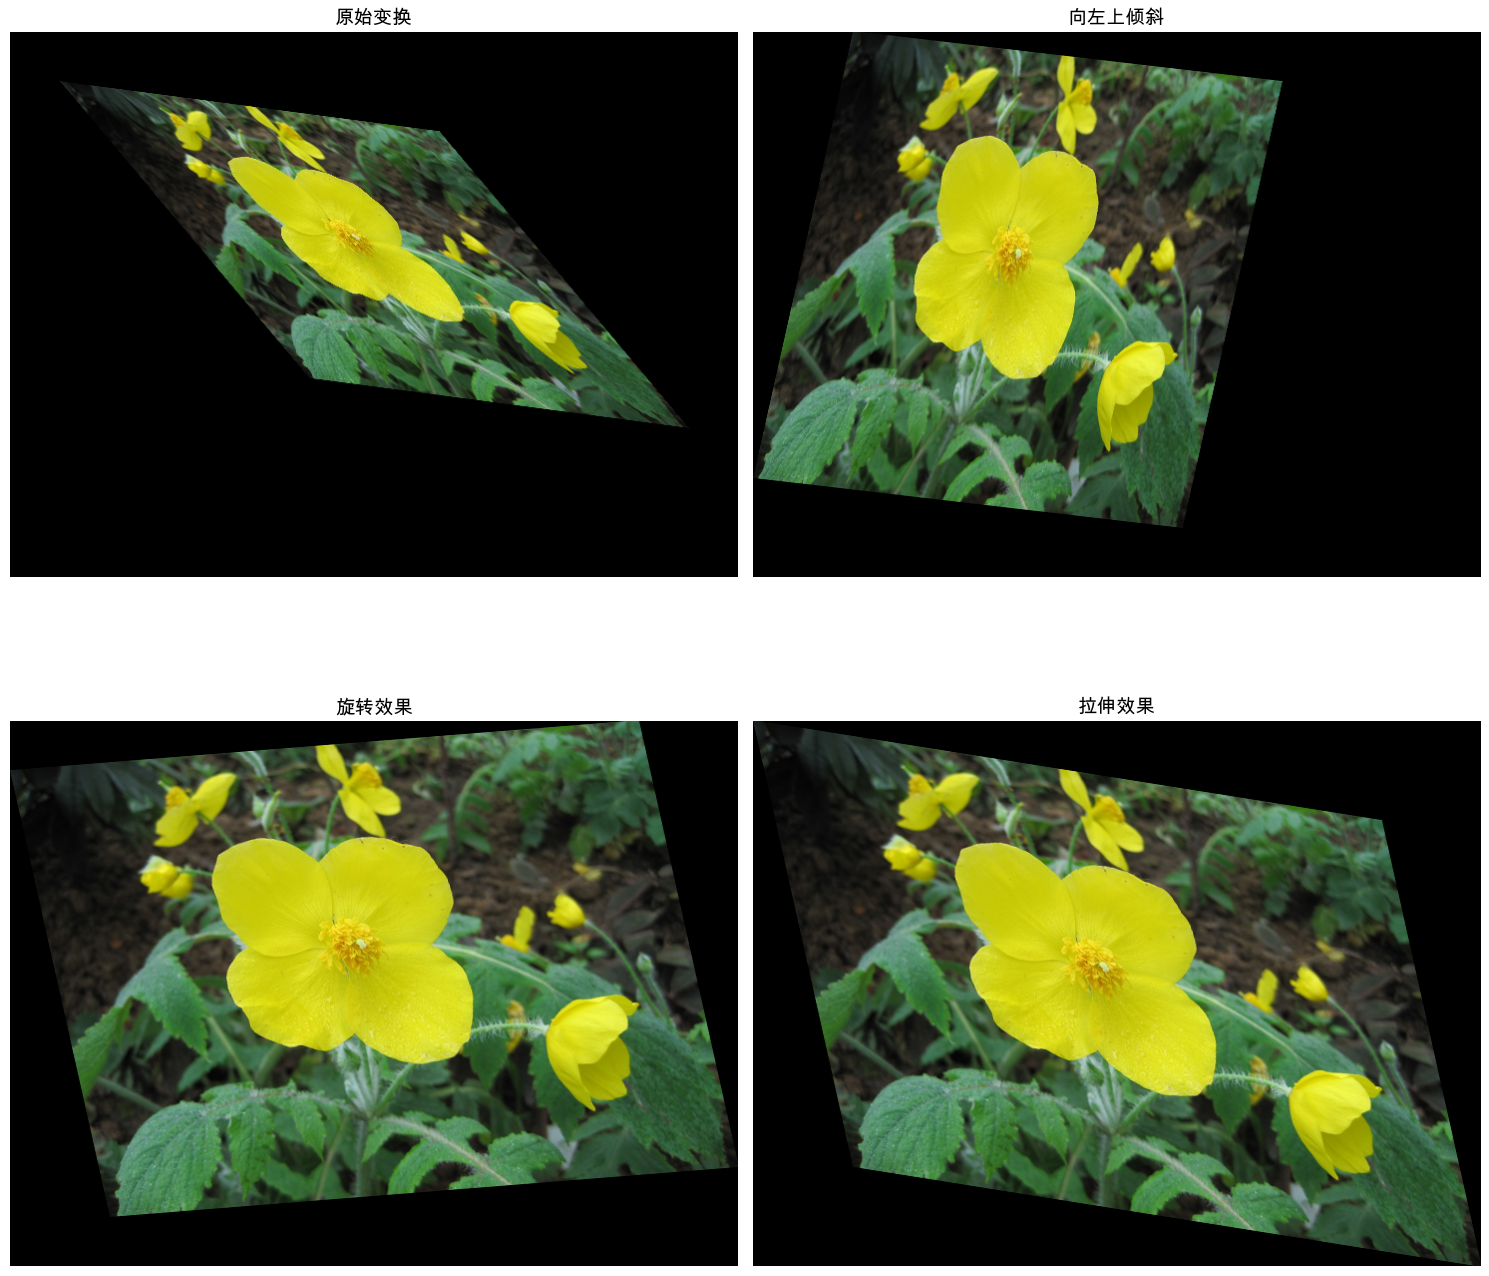

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
# 设置支持中文的字体
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'Microsoft YaHei', 'WenQuanYi Micro Hei']
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题

img = cv2.imread('/Users/xh/workspaces/jupyter/opencv-example/2入门/opencv入门/image0.JPG')
height, width = img.shape[:2]

# 定义多个不同的仿射变换
transforms = []

# 1. 你的原始变换（向右下倾斜）
src1 = np.float32([[0,0], [0,height-1], [width-1,0]])
dst1 = np.float32([[50,50], [300,height-200], [width-300,100]])
transforms.append(('原始变换', src1, dst1))

# 2. 向左上倾斜
src2 = np.float32([[0,0], [0,height-1], [width-1,0]])
dst2 = np.float32([[100,0], [0,height-100], [width-200,50]])
transforms.append(('向左上倾斜', src2, dst2))

# 3. 旋转效果
src3 = np.float32([[0,0], [0,height-1], [width-1,0]])
dst3 = np.float32([[0,50], [100,height-50], [width-100,0]])
transforms.append(('旋转效果', src3, dst3))

# 4. 拉伸效果
src4 = np.float32([[0,0], [0,height-1], [width-1,0]])
dst4 = np.float32([[0,0], [100,height-100], [width-100,100]])
transforms.append(('拉伸效果', src4, dst4))

# 显示所有效果
fig, axes = plt.subplots(2, 2, figsize=(15, 15))

for ax, (title, src, dst) in zip(axes.flat, transforms):
    # 计算仿射变换矩阵
    matAffine = cv2.getAffineTransform(src, dst)
    result = cv2.warpAffine(img, matAffine, (width, height))

    # 显示结果
    img_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    ax.set_title(title, fontsize=14)
    ax.axis('off')

plt.tight_layout()
plt.show()